In [1]:
# TTS_PATH = "/home/erogol/projects/"

In [2]:
import os
import sys
import librosa
import numpy as np
import pandas as pd
from scipy.stats import norm
from tqdm import tqdm_notebook as tqdm
from multiprocessing import Pool
from matplotlib import pylab as plt
from collections import Counter
from TTS.config.shared_configs import BaseDatasetConfig
from TTS.tts.datasets import load_tts_samples
from TTS.tts.datasets.formatters import *
%matplotlib inline

/home/wayne/miniconda3/envs/coqui-tts/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
NUM_PROC = 8
DATASET_CONFIG = BaseDatasetConfig(
        dataset_name="hat_tts_fa_hailu_concat",
        formatter="hat_tts",
        meta_file_train="fa_hailu_concat_v2.json",
        path="/mnt/user_wayne/hat_tts",
        language="hailu",
    )
# DATASET_CONFIG = [
#     BaseDatasetConfig(
#         dataset_name=f"hat_tts_{name}",
#         formatter="hat_tts",
#         meta_file_train=f"{name}.json",
#         path="/mnt/user_wayne/hat_tts",
#         language="sixian" if "sixian" in name else "hailu",
#     )
#     for name in ["fa_sixian_concat", "fa_sixian", "fa_hailu_concat", "fa_hailu"]
# ]

In [4]:
def formatter(root_path, meta_file, **kwargs):  # pylint: disable=unused-argument
    txt_file = os.path.join(root_path, meta_file)
    items = []
    speaker_name = "myspeaker"
    with open(txt_file, "r", encoding="utf-8") as ttf:
        for line in ttf:
            cols = line.split("|")
            wav_file = os.path.join(root_path, "wavs", cols[0] + ".wav")            
            text = cols[1]
            items.append({"text": text, "audio_file": wav_file, "speaker_name": speaker_name, "root_path": root_path})
    return items

In [5]:
# use your own preprocessor at this stage - TTS/datasets/proprocess.py
train_samples, eval_samples = load_tts_samples(DATASET_CONFIG, eval_split=True,)
if eval_samples is not None:
    items = train_samples + eval_samples
else:
    items = train_samples
print(" > Number of audio files: {}".format(len(items)))
print(items[1])

 | > Found 64320 files in /mnt/user_wayne/hat_tts
 > Number of audio files: 64320
{'text': ['h', 'a', 'n', '11', 's', 'a', 'ŋ', '24', ' ', 't', '͡', 's', 'ʰ', 'u', 't', '2', ' ', 'i', '55', 'u', '55', ' ', 'i', '55', 'u', '55', ' ', 'i', '55', 'u', '55', ' ', 'p', 'ʰ', 'u', 'n', '24', ' ', 'k', 'e', '55', ' ', 'i', '5', 'a', 'p', '5', 'e', '31', ' ', '，', ' ', 'k', 'i', '11', 't', 'e', '24', 'u', '24', ' ', 't', '͡', 'ɕ', 'ʰ', 'i', '55', 'u', '55', 't', '͡', 'ɕ', 'ʰ', 'i', '55', 'o', 'ŋ', '55', ' ', 'h', 'e', '55', ' ', 'o', '55', 'i', '55', ' ', 'p', 'o', '31', 'f', 'u', '55', ' ', 'f', 'a', '24', 'p', 'a', '24', 'u', '24', ' ', 'k', 'ʰ', 'i', '55', 'u', 'ŋ', '55', 'i', '55', 'o', 'ŋ', '55'], 'audio_file': '/mnt/user_wayne/hat_tts/wav_concat_v2/fa_sixian/0010118_0.00-6.75.wav', 'speaker_name': 'XF', 'root_path': '/mnt/user_wayne/hat_tts', 'language': 'hailu', 'audio_unique_name': 'hat_tts_fa_hailu_concat#wav_concat_v2/fa_sixian/0010118_0.00-6.75'}


In [6]:
# check wavs if exist
wav_files = []
for item in items:
    wav_file = item["audio_file"].strip()
    wav_files.append(wav_file)
    if not os.path.exists(wav_file):
        print(wav_file)

In [7]:
# show duplicate items
c = Counter(wav_files)
print([item for item, count in c.items() if count > 1])

[]


In [8]:
item

{'text': ['p',
  'o',
  'k',
  '2',
  ' ',
  'e',
  '11',
  ' ',
  'o',
  '55',
  'i',
  '55',
  ' ',
  't',
  '͡',
  's',
  'ʰ',
  'u',
  'k',
  '5',
  ' ',
  't',
  '͡',
  's',
  'ʰ',
  'u',
  'k',
  '5',
  ' ',
  'a',
  '55',
  ' ',
  '，',
  ' ',
  't',
  '͡',
  's',
  'a',
  'ŋ',
  '55',
  ' ',
  't',
  '͡',
  'ɕ',
  'i',
  '24',
  'o',
  'ŋ',
  '24',
  ' ',
  't',
  '͡',
  's',
  'ʰ',
  'a',
  '11',
  'k',
  'u',
  '24',
  'p',
  'ʰ',
  'o',
  '24',
  ' ',
  '，',
  ' ',
  't',
  'ʰ',
  'u',
  'ŋ',
  '11',
  'k',
  'i',
  '11',
  ' ',
  't',
  '͡',
  'ɕ',
  'ʰ',
  'i',
  'p',
  '5',
  ' ',
  't',
  '͡',
  'ɕ',
  'ʰ',
  'i',
  'p',
  '5',
  ' ',
  't',
  '͡',
  'ɕ',
  'ʰ',
  'i',
  '55',
  'a',
  'ŋ',
  '55',
  ' ',
  'l',
  'o',
  '11',
  'i',
  '11'],
 'audio_file': '/mnt/user_wayne/hat_tts/wav_concat_v2/fa_sixian/0014430_1.70-6.75.wav',
 'speaker_name': 'XM',
 'root_path': '/mnt/user_wayne/hat_tts',
 'language': 'hailu',
 'audio_unique_name': 'hat_tts_fa_hailu_concat#wav_concat_v

In [9]:
def load_item(item):
    text = item["text"]
    file_name = item["audio_file"].strip()
    audio, sr = librosa.load(file_name, sr=None)
    audio_len = len(audio) / sr
    text_len = len(text)
    return file_name, text, text_len, audio, audio_len

# This will take a while depending on size of dataset
if NUM_PROC == 1:
    data = []
    for m in tqdm(items):
        data += [load_item(m)]
else:
    with Pool(8) as p:
        data = list(tqdm(p.imap(load_item, items), total=len(items)))

100%|██████████| 64320/64320 [00:51<00:00, 1237.62it/s]


In [10]:
# count words in the dataset
w_count = Counter()
for item in tqdm(data):
    text = item[1]
    for word in text:
        w_count[word] += 1
print(" > Number of words: {}".format(len(w_count)))

100%|██████████| 64320/64320 [00:00<00:00, 120536.59it/s]

 > Number of words: 39


In [11]:
text_vs_durs = {}  # text length vs audio duration
text_len_counter = Counter()  # number of sentences with the keyed length
for item in tqdm(data):
    text = item[1]
    text_len = len(text)
    text_len_counter[text_len] += 1
    audio_len = item[-1]
    try:
        text_vs_durs[text_len] += [audio_len]
    except:
        text_vs_durs[text_len] = [audio_len]

100%|██████████| 64320/64320 [00:00<00:00, 1494389.39it/s]


In [12]:
# text_len vs avg_audio_len, median_audio_len, std_audio_len
text_vs_avg = {}
text_vs_median = {}
text_vs_std = {}
for key, durs in text_vs_durs.items():
    text_vs_avg[key] = np.mean(durs)
    text_vs_median[key] = np.median(durs)
    text_vs_std[key] = np.std(durs)

### Avg audio length per char

In [13]:
for item in data:
    if item[-1] < 2:
        print(item)

('/mnt/user_wayne/hat_tts/wav_concat_v2/fa_sixian/0020247_1.40-4.65.wav', ['h', 'o', 'ʊ', ' ', '，', ' ', 'ŋ', '̩', '31', 's', 'ɨ', 'p', '5', 'ŋ', '̩', '31', ' ', 'k', 'i', ' ', 'd', 'i', ' ', 'l', 'i', '31', 'o', 'ŋ', '31', ' ', 'm', 'o', '11', 't', '͡', 'ɕ', 'ʰ', 'i', '55', 'u', '55', ' ', '，', ' ', 'v', 'o', 'ʊ', ' ', 's', 'a', 'm', '24', 's', 'ɨ', 'p', '5', ' ', 'i', 't', '2'], 60, array([-0.00042725, -0.00061035, -0.00048828, ...,  0.00338745,
        0.00360107,  0.00256348], dtype=float32), 1.9100680272108843)
('/mnt/user_wayne/hat_tts/wav_concat_v2/fa_sixian/0013052_2.75-4.53.wav', ['i', 't', '2', ' ', 'k', 'ʰ', 'i', '24', 'e', 'n', '24', ' ', 'k', 'i', '24', 't', '͡', 's', 'ʰ', 'a', '24', ' ', 't', '͡', 's', 'ʰ', 'a', '24', 'p', 'ʰ', 'a', '11', 'i', '11', ' ', 'i', '24', 'u', '24', ' ', '，', ' ', 'ɕ', 'i', '55', ' ', 't', '͡', 's', 'a', 'k', '2', ' ', '，', ' ', 's', 'u', '55', 's', 'ɨ', '55'], 61, array([-9.1552734e-05, -4.2724609e-04, -4.5776367e-04, ...,
       -3.0517578e-05

In [14]:
sec_per_chars = []
for item in data:
    text = item[1]
    dur = item[-1]
    sec_per_char = dur / len(text)
    sec_per_chars.append(sec_per_char)
# sec_per_char /= len(data)
# print(sec_per_char)

In [15]:
mean = np.mean(sec_per_chars)
std = np.std(sec_per_chars)
print(mean)
print(std)

0.06237738689190012
0.00824508727943523


In [16]:
dist = norm(mean, std)

# find irregular instances long or short voice durations
for item in data:
    text = item[1]
    dur = item[-1]
    sec_per_char = dur / len(text)
    pdf =norm.pdf(sec_per_char)
    if pdf < 0.39:
        print(item)

### Plot Dataset Statistics

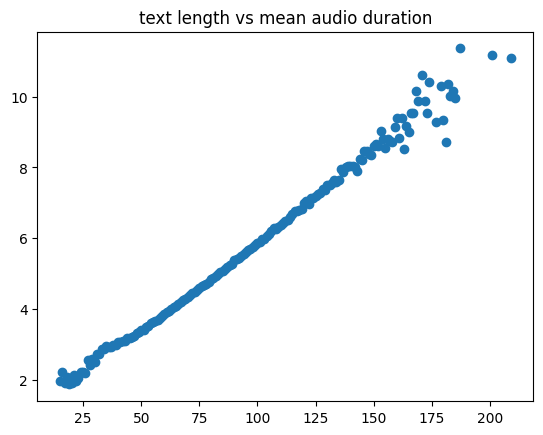

In [17]:
plt.title("text length vs mean audio duration")
plt.scatter(list(text_vs_avg.keys()), list(text_vs_avg.values()))

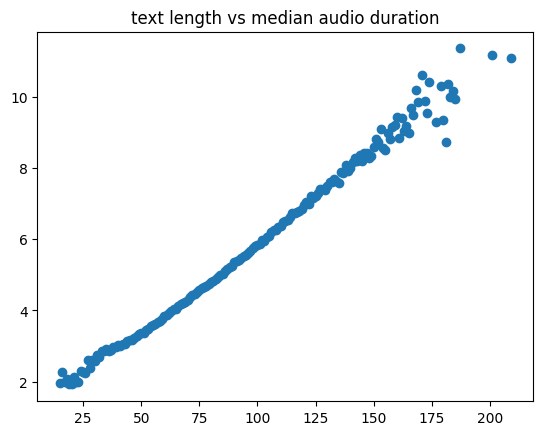

In [18]:
plt.title("text length vs median audio duration")
plt.scatter(list(text_vs_median.keys()), list(text_vs_median.values()))

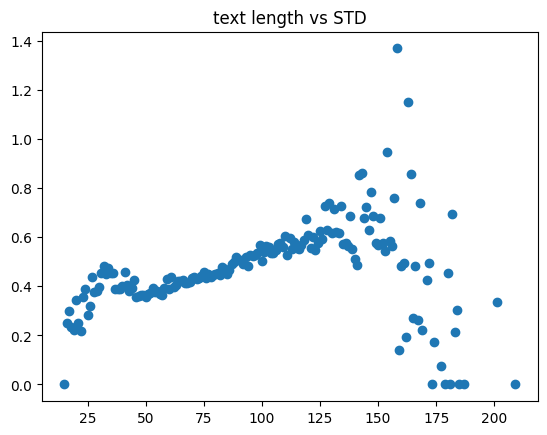

In [19]:
plt.title("text length vs STD")
plt.scatter(list(text_vs_std.keys()), list(text_vs_std.values()))

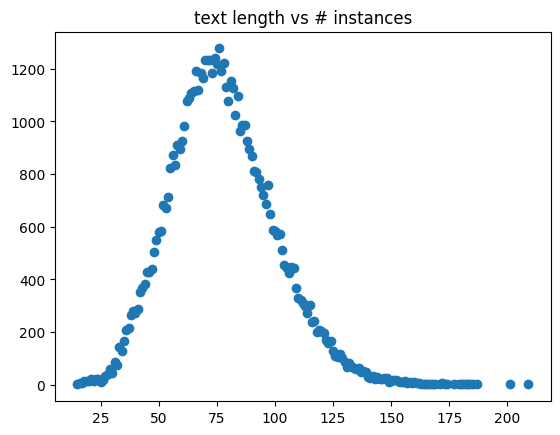

In [20]:
plt.title("text length vs # instances")
plt.scatter(list(text_len_counter.keys()), list(text_len_counter.values()))

### Check words frequencies

In [21]:
w_count_df = pd.DataFrame.from_dict(w_count, orient='index')
w_count_df.sort_values(0, ascending=False, inplace=True)

In [22]:
w_count_df

,0
,679079
55,396855
i,385248
t,322379
24,262132
11,243569
a,217460
o,205563
31,203167
k,201199


In [23]:
# check a certain word
w_count_df.at['minute', 0]

KeyError: 'minute'

<Axes: >

/home/wayne/miniconda3/envs/coqui-tts/lib/python3.10/site-packages/IPython/core/events.py:82: UserWarning: Glyph 65292 (\N{FULLWIDTH COMMA}) missing from current font.
  func(*args, **kwargs)
/home/wayne/miniconda3/envs/coqui-tts/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 65292 (\N{FULLWIDTH COMMA}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


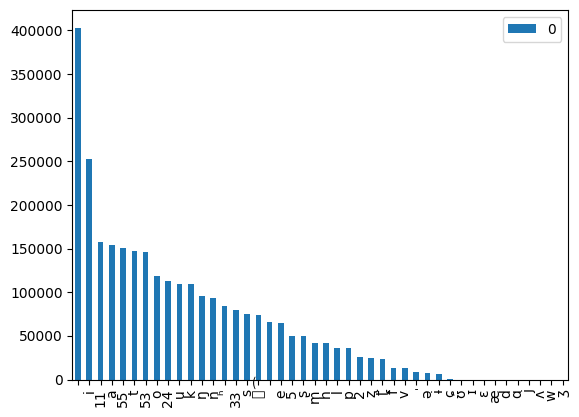

In [ ]:
# fequency bar plot - it takes time!!
w_count_df.plot.bar()